# Ensemble

Autor: Bartosz Perz

In [25]:
!pip install ucimlrepo

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

In [26]:
import itertools
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    make_scorer,
    recall_score
)

### 1. EDA

In [27]:
df = pd.read_csv("./ObesityDataSet_raw_and_data_sinthetic.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


FAVC - czy osoba często spożywa wysokokaloryczne jedzenie

FCVC - czy osoba zazwyczaj je warzywa w posiłkach

NCP - ilość dziennych posiłków

CAEC - czy osoba je między posiłkami

SMOKE - czy dana osoba pali

CH2O  - ilość codziennie wypijanej wody

SCC - czy osoba monitoruje spożywane kalorie

FAF - częstotliwość aktywności fizycznej

TUE - czas korzystania z urządzeń technologicznych (np. telefon komórkowy, gry wideo, telewizja, komputer i inne)

CALC - częstotliwość spożywania alkoholu

MTRANS - najczęściej używany środek transportu

NObeyesdad - poziom otyłości

In [28]:
print(30*"-", "Brakujące dane", 30*"-")
display(df.isnull().sum())

------------------------------ Brakujące dane ------------------------------


,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [29]:
# Podstawowe statystyki opisowe dla zmiennych numerycznych (Wiek, Wzrost, Waga, itp.)
display(df.describe())

# Podstawowe statystyki dla zmiennych kategorycznych
display(df.describe(include=['object']))

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


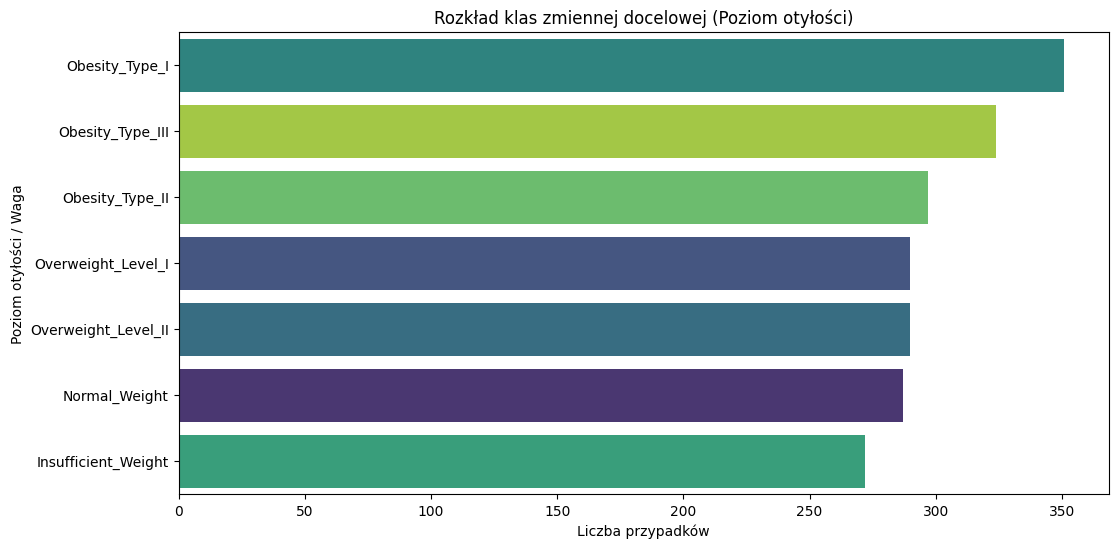

In [30]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, y='NObeyesdad', hue='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='viridis', legend=False)

plt.title('Rozkład klas zmiennej docelowej (Poziom otyłości)')
plt.xlabel('Liczba przypadków')
plt.ylabel('Poziom otyłości / Waga')
plt.show()

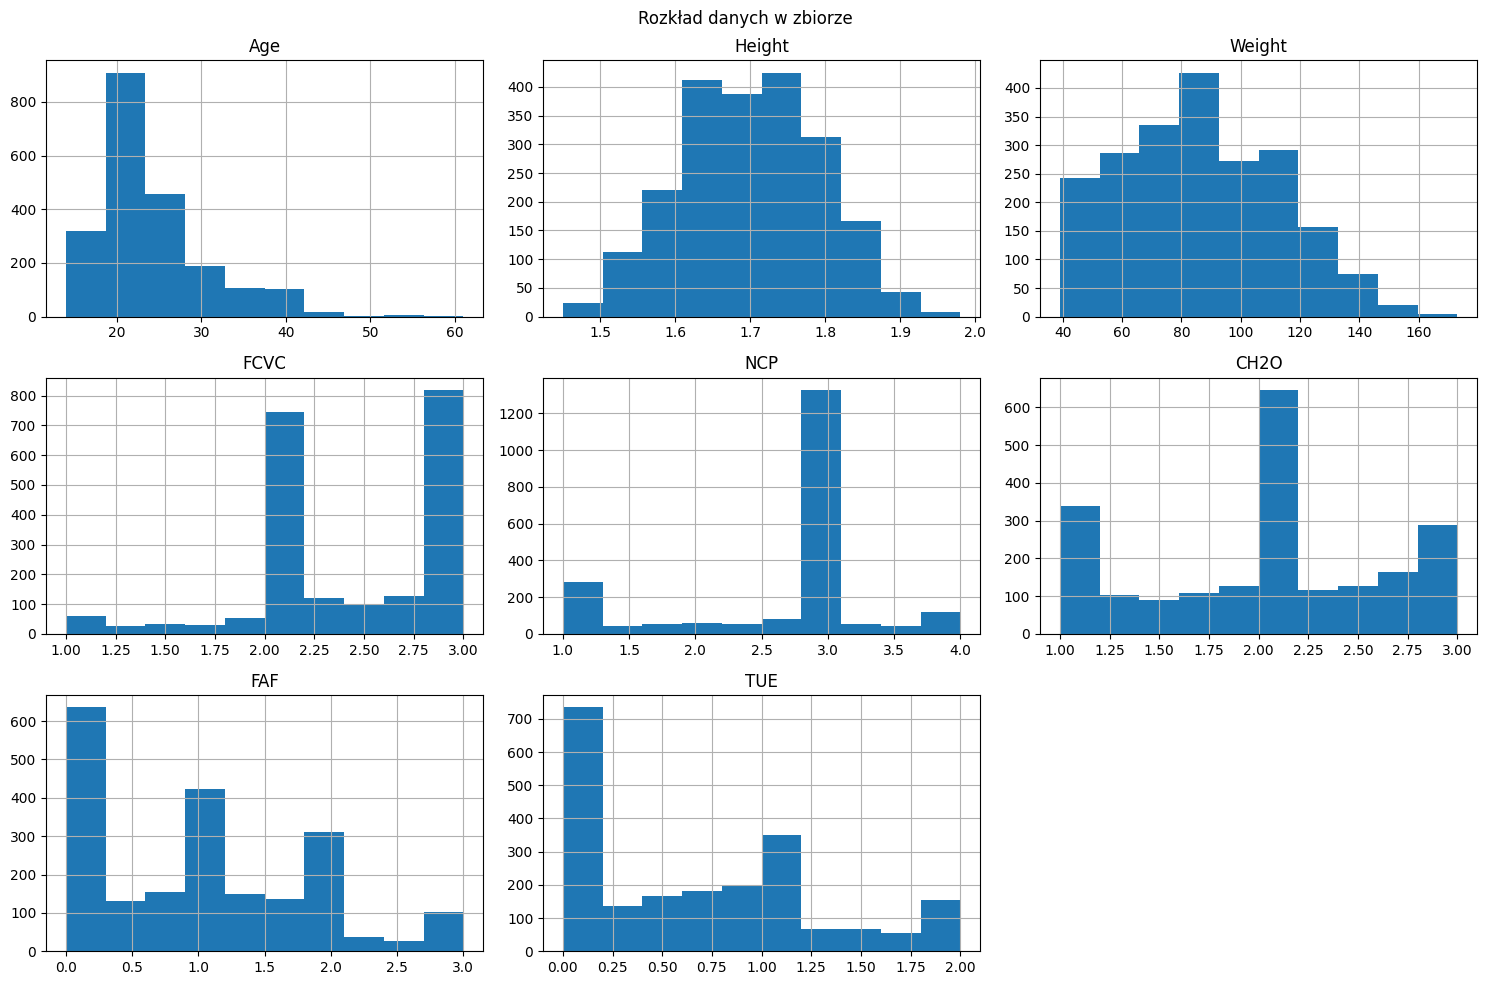

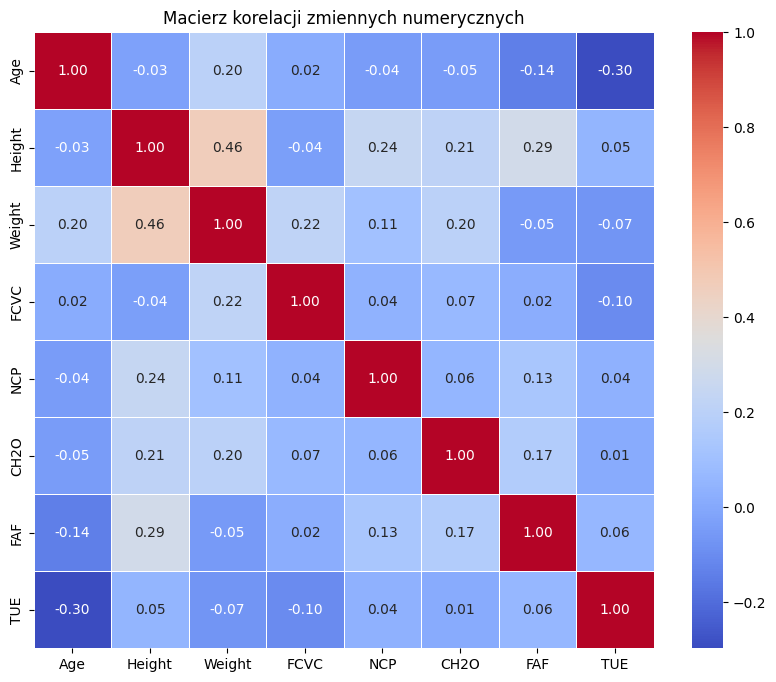

In [31]:
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df.hist(figsize=(15, 10))
plt.suptitle("Rozkład danych w zbiorze")
plt.tight_layout()

# Macierz korelacji - sprawdzenie relacji liniowych między zmiennymi numerycznymi
plt.figure(figsize=(10, 8))
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji zmiennych numerycznych')
plt.show()

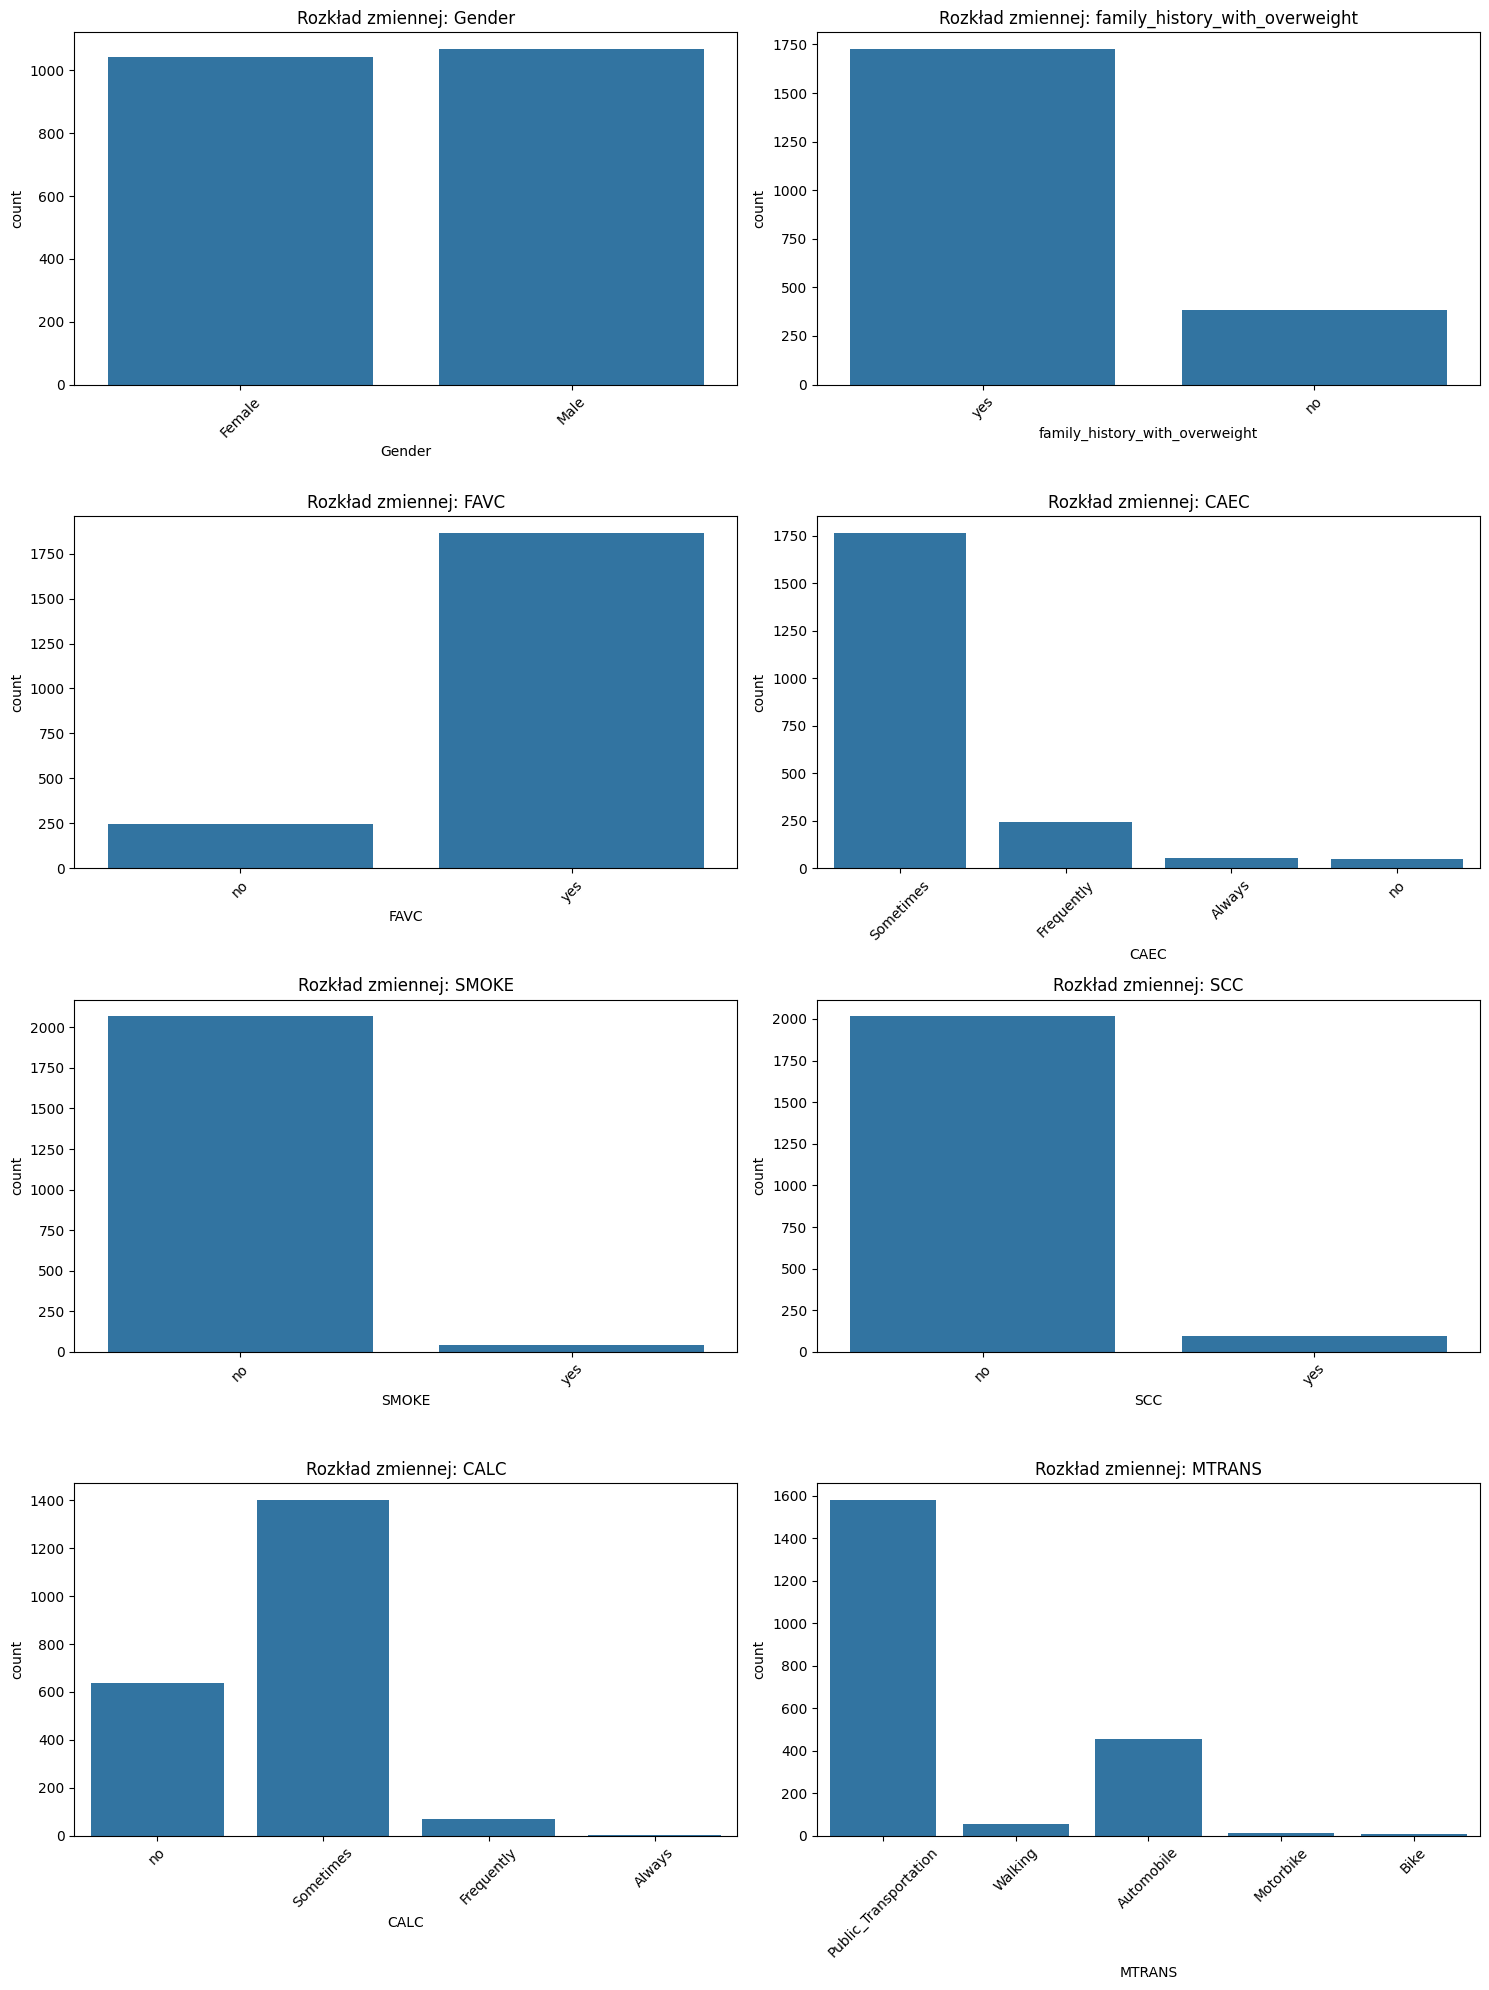

In [32]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Rozkład zmiennej: {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

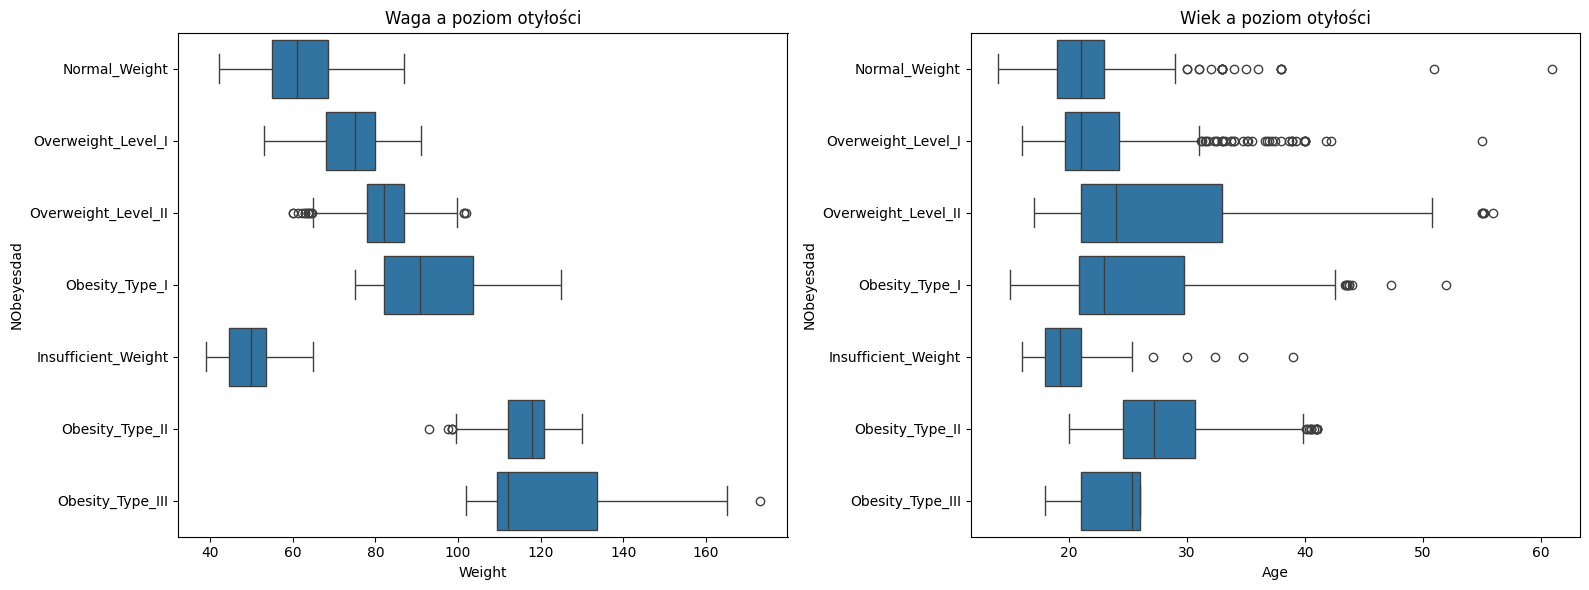

In [33]:
# Związek wagi i wzrostu z otyłością
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Weight', y='NObeyesdad', ax=ax[0])
ax[0].set_title('Waga a poziom otyłości')

sns.boxplot(data=df, x='Age', y='NObeyesdad', ax=ax[1])
ax[1].set_title('Wiek a poziom otyłości')

plt.tight_layout()
plt.show()

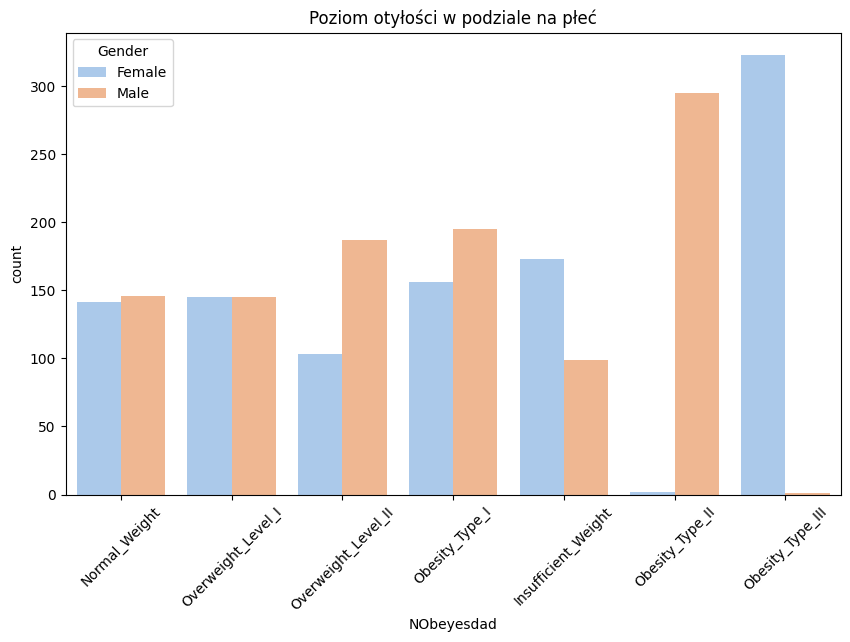

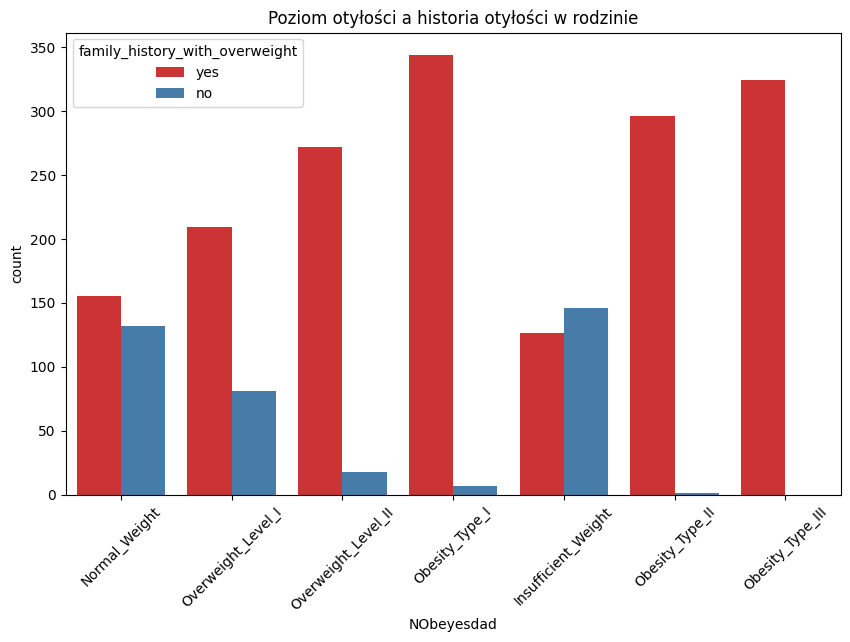

In [34]:
# Płeć a otyłość
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='NObeyesdad', hue='Gender', palette='pastel')
plt.title('Poziom otyłości w podziale na płeć')
plt.xticks(rotation=45)
plt.show()

# Wywiad rodzinny a otyłość
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='NObeyesdad', hue='family_history_with_overweight', palette='Set1')
plt.title('Poziom otyłości a historia otyłości w rodzinie')
plt.xticks(rotation=45)
plt.show()

### Preprocesing

In [35]:
df = pd.read_csv("./ObesityDataSet_raw_and_data_sinthetic.csv")
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Kodowanie zmiennej docelowej (7 klas otyłości)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(np.unique(y_encoded))

# Identyfikacja kolumn
num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

# Preprocesor: One-Hot dla tekstu, Standaryzacja dla liczb
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ])

# Podział na zbiór treningowy i testowy (80/20) - stratyfikacja jest obowiązkowa!
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

### Uczenie modeli

In [36]:
def evaluate_model_standardized(name, model_pipeline, X_train, y_train, X_test, y_test):
    print(f"\n{'-'*50}")
    print(f"MODEL: {name}")
    print(f"{'-'*50}")

    # Trening (mierzymy czas, ale nie oceniamy po nim przydatności wdrożeniowej)
    model_pipeline.fit(X_train, y_train)

    # Predykcja (Tutaj czas jest krytyczny dla wdrożenia w przychodni)
    start_pred = time.time()
    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)
    pred_time_ms = (time.time() - start_pred) * 1000 # konwersja na milisekundy

    # Obliczenie metryk
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    mean_confidence = np.mean(np.max(y_proba, axis=1))

    # Brier Score dla wielu klas
    y_test_one_hot = np.eye(num_classes)[y_test]
    brier_score = np.mean(np.sum((y_proba - y_test_one_hot)**2, axis=1))

    # Raport
    print(f"Skuteczność:")
    print(f"  -> Zbalansowana dokładność: {bal_acc:.4f}")
    print(f"  -> Brier Score:             {brier_score:.4f} (Bliżej 0.0 = lepsza kalibracja)")
    print(f"  -> Średnia pewność diagnozy:{mean_confidence:.2%}")
    print(f"Wydajność wdrożeniowa:")
    print(f"  -> Czas predykcji ({len(X_test)} pacjentów): {pred_time_ms:.2f} ms")

    return {
        "Model": name,
        "Balanced_Accuracy": bal_acc,
        "Brier_Score": brier_score,
        "Confidence": mean_confidence,
        "Prediction_Time_ms": pred_time_ms
    }

#### Pojedyncze drzewa decyzyjne i regresja logistyczna

In [37]:
models = {
    "Drzewo Decyzyjne (Płytkie - max_depth=4)": Pipeline([
        ('prep', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=4, random_state=42))
    ]),
    "Regresja Logistyczna (Interpretowalne Wagi)": Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
}

for name, pipeline in models.items():
    res = evaluate_model_standardized(name, pipeline, X_train, y_train, X_test, y_test)


--------------------------------------------------
MODEL: Drzewo Decyzyjne (Płytkie - max_depth=4)
--------------------------------------------------
Skuteczność:
  -> Zbalansowana dokładność: 0.7756
  -> Brier Score:             0.3334 (Bliżej 0.0 = lepsza kalibracja)
  -> Średnia pewność diagnozy:79.28%
Wydajność wdrożeniowa:
  -> Czas predykcji (423 pacjentów): 41.40 ms

--------------------------------------------------
MODEL: Regresja Logistyczna (Interpretowalne Wagi)
--------------------------------------------------
Skuteczność:
  -> Zbalansowana dokładność: 0.8769
  -> Brier Score:             0.2231 (Bliżej 0.0 = lepsza kalibracja)
  -> Średnia pewność diagnozy:74.84%
Wydajność wdrożeniowa:
  -> Czas predykcji (423 pacjentów): 41.62 ms


#### Bagging

In [38]:
# ==========================================
# 1. DEFINICJA MODELI BAZOWYCH I PARAMETRÓW
# ==========================================
base_models = {
    "Płytkie Drzewo": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Głębokie Drzewo": DecisionTreeClassifier(max_depth=None, random_state=42),
    "Regresja Logistyczna": LogisticRegression(max_iter=1000, random_state=42)
}

# Definiujemy wartości do przetestowania
# Ograniczamy n_estimators do 10 i 50, aby wyraźnie zobaczyć przeskok wydajnościowy
n_estimators_list = [10, 50]
bootstrap_list = [True, False]
bootstrap_features_list = [True, False]

# Generujemy wszystkie możliwe kombinacje parametrów
param_combinations = list(itertools.product(n_estimators_list, bootstrap_list, bootstrap_features_list))

bagging_results = []

# ==========================================
# 2. PĘTLA BADAWCZA (Eksperyment)
# ==========================================
for base_name, base_est in base_models.items():
    print(f"-> Trenowanie wariantów dla: {base_name}")

    for n_est, bs, bs_feat in param_combinations:
        # Konstrukcja specyficznego wariantu modelu
        bagging_clf = BaggingClassifier(
            estimator=base_est,
            n_estimators=n_est,
            bootstrap=bs,
            bootstrap_features=bs_feat,
            random_state=42,
            n_jobs=-1 # Wykorzystanie wszystkich rdzeni do treningu
        )

        # Obudowanie w potok z naszym preprocesorem
        pipeline = Pipeline([
            ('prep', preprocessor),
            ('clf', bagging_clf)
        ])

        # Trening
        pipeline.fit(X_train, y_train)

        # Pomiary wdrożeniowe (Predykcja)
        start_pred = time.time()
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)
        pred_time_ms = (time.time() - start_pred) * 1000

        # Obliczenie metryk
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        mean_conf = np.mean(np.max(y_proba, axis=1))
        y_test_one_hot = np.eye(num_classes)[y_test]
        brier_score = np.mean(np.sum((y_proba - y_test_one_hot)**2, axis=1))

        # Zapis wyników
        bagging_results.append({
            "Model_Bazowy": base_name,
            "n_estimators": n_est,
            "bootstrap": bs,
            "bootstrap_features": bs_feat,
            "Balanced_Accuracy": round(bal_acc, 4),
            "Brier_Score": round(brier_score, 4),
            "Confidence": f"{mean_conf:.1%}",
            "Pred_Time_ms": round(pred_time_ms, 2)
        })

# ==========================================
# 3. ANALIZA WYNIKÓW
# ==========================================
# Konwersja do DataFrame dla czytelności
bagging_df = pd.DataFrame(bagging_results)

# Wyświetlamy 5 najlepszych konfiguracji posortowanych po najważniejszej dla nas mierze diagnostycznej (Brier Score)
print("\nTop 5 wariantów Baggingu pod kątem kalibracji (Brier Score):")
display(bagging_df.sort_values(by="Brier_Score", ascending=True).head(5))

# Wyświetlamy 5 najlżejszych wariantów (najszybszy czas predykcji)
print("\nTop 5 wariantów Baggingu pod kątem wydajności (Czas predykcji):")
display(bagging_df.sort_values(by="Pred_Time_ms", ascending=True).head(5))

-> Trenowanie wariantów dla: Płytkie Drzewo
-> Trenowanie wariantów dla: Głębokie Drzewo
-> Trenowanie wariantów dla: Regresja Logistyczna

Top 5 wariantów Baggingu pod kątem kalibracji (Brier Score):


,Model_Bazowy,n_estimators,bootstrap,bootstrap_features,Balanced_Accuracy,Brier_Score,Confidence,Pred_Time_ms
13,Głębokie Drzewo,50,True,False,0.9501,0.0785,92.5%,228.86
9,Głębokie Drzewo,10,True,False,0.9403,0.0862,93.1%,137.95
14,Głębokie Drzewo,50,False,True,0.9452,0.1000,84.4%,204.42
12,Głębokie Drzewo,50,True,True,0.9580,0.1008,82.0%,220.09
11,Głębokie Drzewo,10,False,False,0.9168,0.1580,99.0%,164.86



Top 5 wariantów Baggingu pod kątem wydajności (Czas predykcji):


,Model_Bazowy,n_estimators,bootstrap,bootstrap_features,Balanced_Accuracy,Brier_Score,Confidence,Pred_Time_ms
19,Regresja Logistyczna,10,False,False,0.8769,0.2231,74.8%,65.80
18,Regresja Logistyczna,10,False,True,0.7871,0.3946,53.9%,66.42
16,Regresja Logistyczna,10,True,True,0.7891,0.3953,54.3%,70.78
21,Regresja Logistyczna,50,True,False,0.8724,0.2269,74.5%,80.75
23,Regresja Logistyczna,50,False,False,0.8769,0.2231,74.8%,82.02


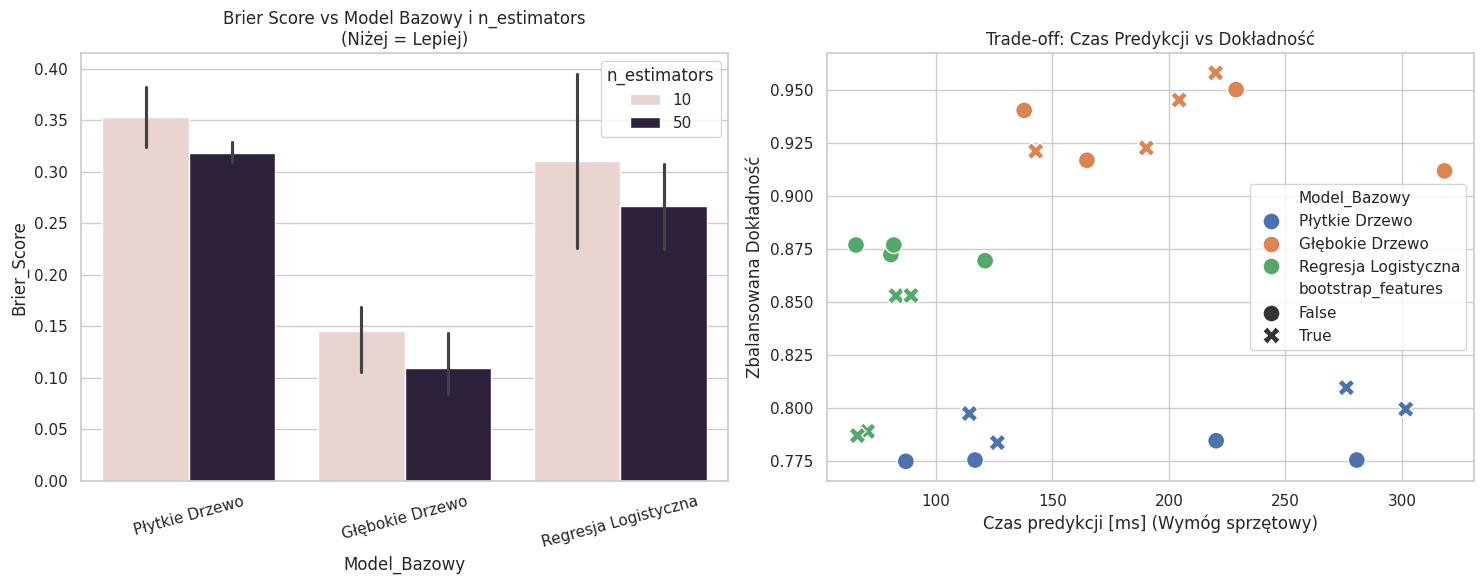

In [39]:
# Ustawienie stylu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Wykres 1: Wpływ parametrów na Brier Score
plt.subplot(1, 2, 1)
# Kategoryzujemy na osi X modele, a kolorami (hue) oznaczamy liczbę estymatorów
sns.barplot(data=bagging_df, x='Model_Bazowy', y='Brier_Score', hue='n_estimators')
plt.title('Brier Score vs Model Bazowy i n_estimators\n(Niżej = Lepiej)')
plt.xticks(rotation=15)

# Wykres 2: Trade-off między Czasem predykcji a Zbalansowaną Dokładnością
plt.subplot(1, 2, 2)
# Scatterplot świetnie pokazuje trade-off. Rozmiar kropki to liczba estymatorów.
sns.scatterplot(data=bagging_df, x='Pred_Time_ms', y='Balanced_Accuracy',
                hue='Model_Bazowy', style='bootstrap_features', s=150)
plt.title('Trade-off: Czas Predykcji vs Dokładność')
plt.xlabel('Czas predykcji [ms] (Wymóg sprzętowy)')
plt.ylabel('Zbalansowana Dokładność')

plt.tight_layout()
plt.show()

#### Boosting

In [40]:

# ==========================================
# 1. DEFINICJA MODELI BAZOWYCH I SIATKI PARAMETRÓW
# ==========================================
adaboost_base_models = {
    "AdaBoost (Płytkie Drzewo)": DecisionTreeClassifier(max_depth=4, random_state=42),
    "AdaBoost (Regresja Logistyczna)": LogisticRegression(max_iter=1000, random_state=42)
}

# Parametry do zbadania relacji (Trade-off)
n_estimators_list = [50, 150]
learning_rate_list = [0.01, 0.1, 0.5]

boosting_results = []

# ==========================================
# 2. PĘTLA BADAWCZA (Eksperyment)
# ==========================================
print("Uruchamiam eksperymenty dla AdaBoost...")
for base_name, base_est in adaboost_base_models.items():
    print(f"-> Trenowanie wariantów dla: {base_name}")
    for n_est, lr in itertools.product(n_estimators_list, learning_rate_list):

        ada_clf = AdaBoostClassifier(
            estimator=base_est,
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42
        )

        pipeline = Pipeline([('prep', preprocessor), ('clf', ada_clf)])
        pipeline.fit(X_train, y_train)

        start_pred = time.time()
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)
        pred_time_ms = (time.time() - start_pred) * 1000

        bal_acc = balanced_accuracy_score(y_test, y_pred)
        mean_conf = np.mean(np.max(y_proba, axis=1))
        y_test_one_hot = np.eye(num_classes)[y_test]
        brier_score = np.mean(np.sum((y_proba - y_test_one_hot)**2, axis=1))

        boosting_results.append({
            "Algorytm": base_name,
            "n_estimators": n_est,
            "learning_rate": lr,
            "Balanced_Accuracy": round(bal_acc, 4),
            "Brier_Score": round(brier_score, 4),
            "Confidence": mean_conf,
            "Pred_Time_ms": round(pred_time_ms, 2)
        })

print("\nUruchamiam eksperymenty dla Gradient Boosting...")
for n_est, lr in itertools.product(n_estimators_list, learning_rate_list):

    gb_clf = GradientBoostingClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )

    pipeline = Pipeline([('prep', preprocessor), ('clf', gb_clf)])
    pipeline.fit(X_train, y_train)

    start_pred = time.time()
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)
    pred_time_ms = (time.time() - start_pred) * 1000

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    mean_conf = np.mean(np.max(y_proba, axis=1))
    y_test_one_hot = np.eye(num_classes)[y_test]
    brier_score = np.mean(np.sum((y_proba - y_test_one_hot)**2, axis=1))

    boosting_results.append({
        "Algorytm": "Gradient Boosting (Tree)",
        "n_estimators": n_est,
        "learning_rate": lr,
        "Balanced_Accuracy": round(bal_acc, 4),
        "Brier_Score": round(brier_score, 4),
        "Confidence": mean_conf,
        "Pred_Time_ms": round(pred_time_ms, 2)
    })

# ==========================================
# 3. ANALIZA WYNIKÓW
# ==========================================
# Konwersja do DataFrame dla czytelności
boosting_df = pd.DataFrame(boosting_results)

# Wyświetlamy 5 najlepszych konfiguracji pod kątem kalibracji (Brier Score)
print("\nTop 5 wariantów Boostingu pod kątem kalibracji (Brier Score):")
display(boosting_df.sort_values(by="Brier_Score", ascending=True).head(5))

# Wyświetlamy 5 najlżejszych wariantów pod kątem ograniczeń sprzętowych przychodni (Czas predykcji)
print("\nTop 5 wariantów Boostingu pod kątem wydajności (Czas predykcji):")
display(boosting_df.sort_values(by="Pred_Time_ms", ascending=True).head(5))

Uruchamiam eksperymenty dla AdaBoost...
-> Trenowanie wariantów dla: AdaBoost (Płytkie Drzewo)
-> Trenowanie wariantów dla: AdaBoost (Regresja Logistyczna)

Uruchamiam eksperymenty dla Gradient Boosting...

Top 5 wariantów Boostingu pod kątem kalibracji (Brier Score):


,Algorytm,n_estimators,learning_rate,Balanced_Accuracy,Brier_Score,Confidence,Pred_Time_ms
16,Gradient Boosting (Tree),150,0.10,0.9471,0.0763,0.963488,34.37
17,Gradient Boosting (Tree),150,0.50,0.9521,0.0887,0.994317,32.15
14,Gradient Boosting (Tree),50,0.50,0.9398,0.0987,0.984319,21.75
13,Gradient Boosting (Tree),50,0.10,0.9249,0.1118,0.880703,25.37
15,Gradient Boosting (Tree),150,0.01,0.8605,0.2589,0.649013,49.49



Top 5 wariantów Boostingu pod kątem wydajności (Czas predykcji):


,Algorytm,n_estimators,learning_rate,Balanced_Accuracy,Brier_Score,Confidence,Pred_Time_ms
14,Gradient Boosting (Tree),50,0.50,0.9398,0.0987,0.984319,21.75
13,Gradient Boosting (Tree),50,0.10,0.9249,0.1118,0.880703,25.37
17,Gradient Boosting (Tree),150,0.50,0.9521,0.0887,0.994317,32.15
16,Gradient Boosting (Tree),150,0.10,0.9471,0.0763,0.963488,34.37
12,Gradient Boosting (Tree),50,0.01,0.7603,0.5196,0.377438,35.44


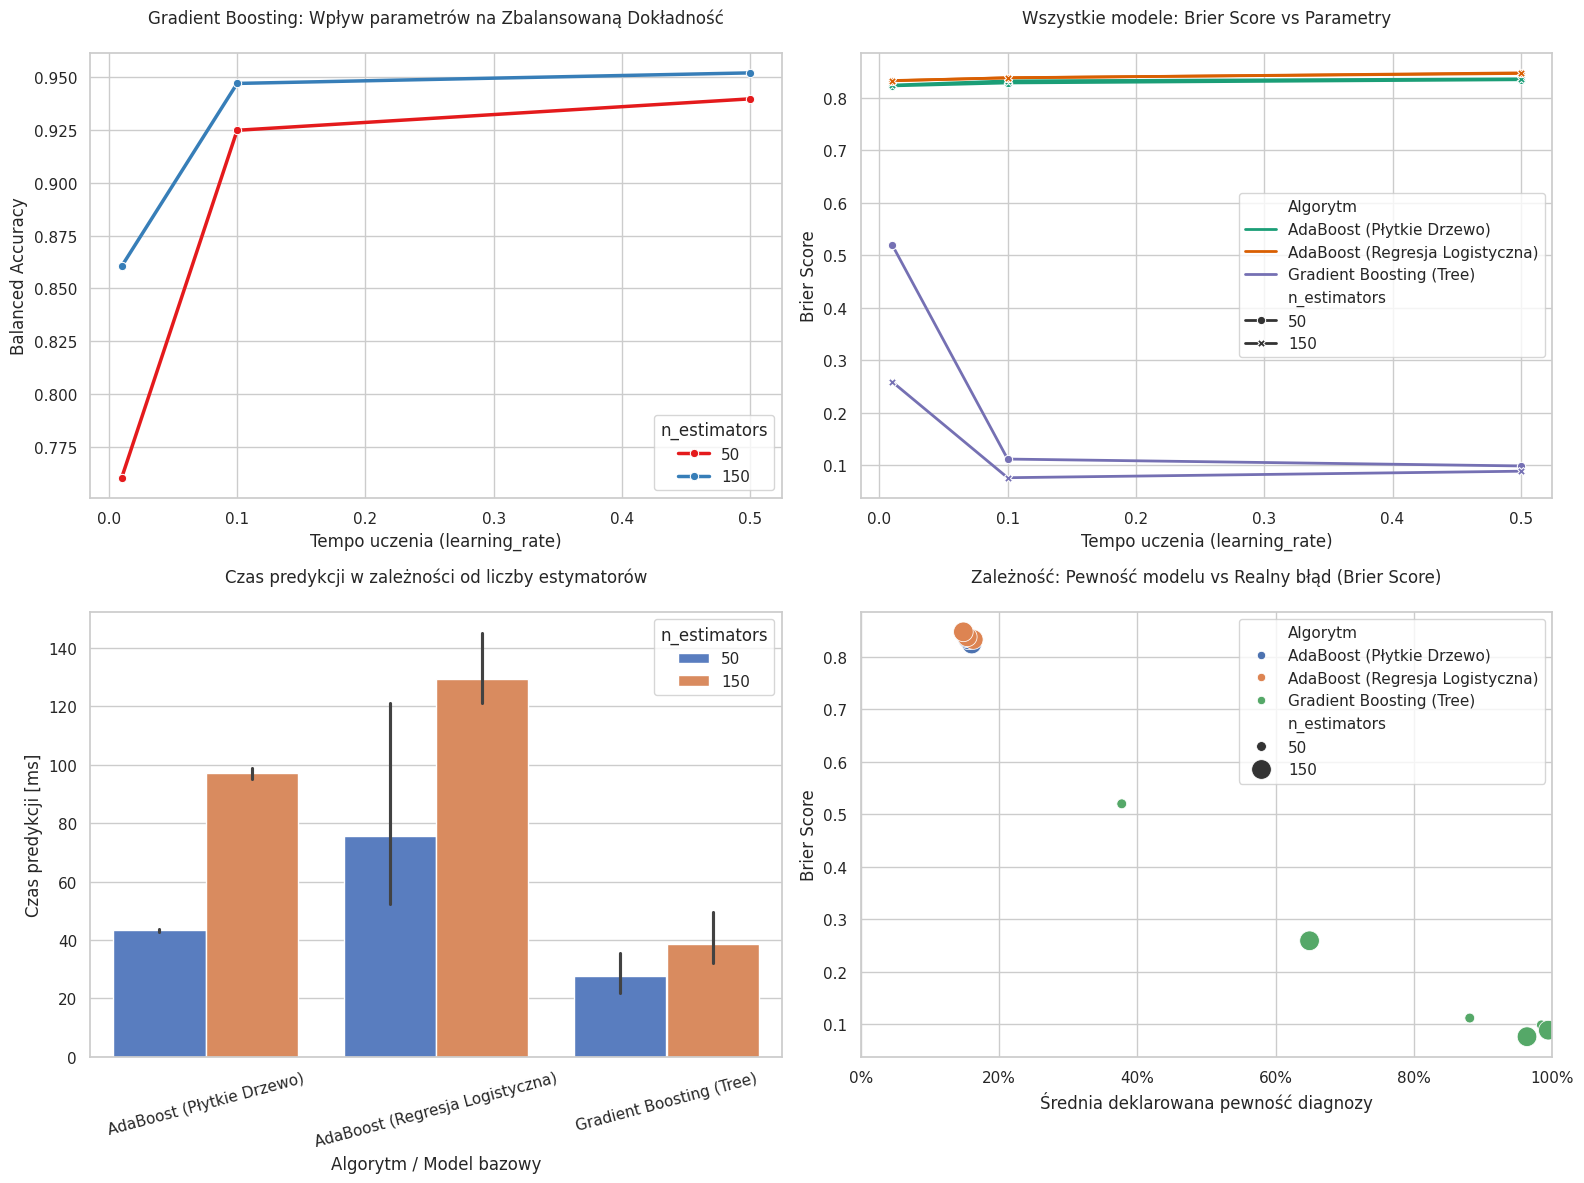

In [41]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Wykres: Wpływ learning_rate i n_estimators na Dokładność (dla Gradient Boosting)
gb_data = boosting_df[boosting_df['Algorytm'] == 'Gradient Boosting (Tree)']
sns.lineplot(ax=axes[0, 0], data=gb_data, x='learning_rate', y='Balanced_Accuracy',
             hue='n_estimators', marker='o', palette='Set1', linewidth=2.5)
axes[0, 0].set_title('Gradient Boosting: Wpływ parametrów na Zbalansowaną Dokładność\n')
axes[0, 0].set_xlabel('Tempo uczenia (learning_rate)')
axes[0, 0].set_ylabel('Balanced Accuracy')

# 2. Wykres: Wpływ parametrów na Brier Score (Kalibracja - kluczowe dla lekarza)
sns.lineplot(ax=axes[0, 1], data=boosting_df, x='learning_rate', y='Brier_Score',
             hue='Algorytm', style='n_estimators', markers=True, dashes=False, palette='Dark2', linewidth=2)
axes[0, 1].set_title('Wszystkie modele: Brier Score vs Parametry\n')
axes[0, 1].set_xlabel('Tempo uczenia (learning_rate)')
axes[0, 1].set_ylabel('Brier Score')

# 3. Wykres: Koszt obliczeniowy w przychodniach wiejskich (Czas predykcji)
sns.barplot(ax=axes[1, 0], data=boosting_df, x='Algorytm', y='Pred_Time_ms', hue='n_estimators', palette='muted')
axes[1, 0].set_title('Czas predykcji w zależności od liczby estymatorów\n')
axes[1, 0].set_xlabel('Algorytm / Model bazowy')
axes[1, 0].set_ylabel('Czas predykcji [ms]')
axes[1, 0].tick_params(axis='x', rotation=15)


# 4. Wykres: Pewność siebie modelu (Confidence) a Brier Score
# Zakładamy, że w dataframe "boosting_df" kolumna "Confidence" jest liczbą float (np. 0.163, 0.994)
# Jeśli jeszcze jej nie odwróciłeś do liczb, upewnij się, że zbierasz surowe dane liczbowe!

sns.scatterplot(ax=axes[1, 1], data=boosting_df, x='Confidence', y='Brier_Score',
                hue='Algorytm', size='n_estimators', sizes=(50, 200), palette='deep')

axes[1, 1].set_title('Zależność: Pewność modelu vs Realny błąd (Brier Score)\n')
axes[1, 1].set_xlabel('Średnia deklarowana pewność diagnozy')
axes[1, 1].set_ylabel('Brier Score')

# --- KLUCZOWA POPRAWKA: Automatyczne formatowanie liczb na osi X jako procenty ---
axes[1, 1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Opcjonalnie: Możesz też wymusić stałe granice od 0% do 100%, żeby wykres był czytelniejszy:
axes[1, 1].set_xlim(0.0, 1.0)

plt.tight_layout()
plt.show()

#### Stacking & Voting

In [42]:

# ==========================================
# 1. DEFINICJA MODELI SKŁADOWYCH (Zróżnicowana architektura)
# ==========================================
# Dobieramy parametry tak, aby modele były lekkie i optymalne dla wiejskich przychodni
base_experts = [
    ('gb', GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
]

# ==========================================
# 2. KONSTRUKCJA KOMITETÓW
# ==========================================

# A. Soft Voting: Uśrednia surowe prawdopodobieństwa wygenerowane przez 3 ekspertów.
# Jest to potężna metoda na redukcję błędu kalibracji (Brier Score).
voting_hybrid = VotingClassifier(estimators=base_experts, voting='soft')

# B. Stacking: Przekazuje przewidywania 3 ekspertów do "meta-modelu" (Regresji Logistycznej),
# który uczy się, komu w jakich sytuacjach ufać najbardziej. Używa 5-krotnej walidacji krzyżowej.
stacking_hybrid = StackingClassifier(
    estimators=base_experts,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)

# Definiujemy zestaw do porównania, w tym pojedynczego "eksperta" (Gradient Boosting) jako punkt odniesienia
ensemble_models = {
    "Pojedynczy Ekspert (Gradient Boosting)": Pipeline([
        ('prep', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42))
    ]),
    "Komitet: Soft Voting (GB + RF + LR)": Pipeline([
        ('prep', preprocessor),
        ('clf', voting_hybrid)
    ]),
    "Komitet: Stacking (Meta-model: LogReg)": Pipeline([
        ('prep', preprocessor),
        ('clf', stacking_hybrid)
    ])
}

# ==========================================
# 3. URUCHOMIENIE STANDARYZOWANEJ EWALUACJI
# ==========================================
hybrid_results = []

for name, pipeline in ensemble_models.items():
    res = evaluate_model_standardized(name, pipeline, X_train, y_train, X_test, y_test)
    hybrid_results.append(res)

# Konwersja do czytelnego zestawienia końcowego
hybrid_df = pd.DataFrame(hybrid_results)
print("\n=== KOŃCOWE PORÓWNANIE ARCHITEKTUR ===")
display(hybrid_df)


--------------------------------------------------
MODEL: Pojedynczy Ekspert (Gradient Boosting)
--------------------------------------------------
Skuteczność:
  -> Zbalansowana dokładność: 0.9249
  -> Brier Score:             0.1118 (Bliżej 0.0 = lepsza kalibracja)
  -> Średnia pewność diagnozy:88.07%
Wydajność wdrożeniowa:
  -> Czas predykcji (423 pacjentów): 23.05 ms

--------------------------------------------------
MODEL: Komitet: Soft Voting (GB + RF + LR)
--------------------------------------------------
Skuteczność:
  -> Zbalansowana dokładność: 0.9365
  -> Brier Score:             0.1902 (Bliżej 0.0 = lepsza kalibracja)
  -> Średnia pewność diagnozy:69.84%
Wydajność wdrożeniowa:
  -> Czas predykcji (423 pacjentów): 49.55 ms

--------------------------------------------------
MODEL: Komitet: Stacking (Meta-model: LogReg)
--------------------------------------------------
Skuteczność:
  -> Zbalansowana dokładność: 0.9388
  -> Brier Score:             0.0889 (Bliżej 0.0 = lep

,Model,Balanced_Accuracy,Brier_Score,Confidence,Prediction_Time_ms
0,Pojedynczy Ekspert (Gradient Boosting),0.924934,0.111841,0.880703,23.050785
1,Komitet: Soft Voting (GB + RF + LR),0.936505,0.190175,0.698434,49.552441
2,Komitet: Stacking (Meta-model: LogReg),0.938785,0.088888,0.937135,50.757408


#### Wnioski

Zaczynając od komitetetu Soft Voting. Osiągnął świetną dokładność (niemal 93.6%), ale jego Brier Score jest wysoki i wynosi aż 0.190. Oznacza to, że model wprawdzie trafnie zgaduje klasy w większości przypadków, ale gdy się myli, bywa źle skalibrowany – nie potrafi uczciwie ocenić ryzyka u pacjentów "na granicy" (np. między nadwagą a otyłością I stopnia).

Z kolei modele takie jak Płytkie Drzewo Decyzyjne deklarują średnią pewność siebie na poziomie prawie 80%, podczas gdy ich realny błąd (Brier Score) to katastrofalne 0.3334. Wdrożenie takiego modelu byłoby niebezpieczne, ponieważ oszukiwałoby lekarza fałszywym poczuciem bezpieczeństwa.

Bagging Regresji Logistycznej: To model, którego wdrożenie byłoby stratą zasobów. Regresja logistyczna jako pojedynczy model osiąga dokładność ~87.6% przy czasie 66 ms. Obudowanie jej algorytmem Baggingu daje 87.6% dokładności, ale wydłuża czas obliczeń do blisko 80 ms. Wynika to z faktu, że modele liniowe są stabilne i uśrednianie ich w komitetach nie daje przyrostu wiedzy, a jedynie marnuje moc procesora.

Głębokie Drzewa w Baggingu: Choć osiągają genialne wyniki kalibracji (Brier 0.078) i dokładności (95%), są zbyt ciężkie dla starych komputerów. Generują czasy predykcji rzędu 200-330 ms, więc takie modele są za ciężkie dla naszych warunków.

Stacking: Mimo wybitnego Brier Score (0.088), meta-model oparty na Stackingu wymaga przeliczenia danych przez 3 inne algorytmy. Zajmuje to 56.3 ms, a mamy szybszą i skuteczniejszą opcję.

Po przeanalizowaniu wszystkich kompromisów (Trade-offs) pomiędzy bezpieczeństwem pacjenta, zaufaniem lekarza i wydajnością sprzętową, bezwzględnym zwycięzcą całego badania jest **Zoptymalizowany Gradient Boosting** (n_estimators=150, learning_rate=0.1)

1. Bezkonkurencyjna Kalibracja (Brier Score: 0.076): Jest to najlepszy wynik w całym badaniu (niższy nawet od skomplikowanego komitetu Stacking). Ten model myli się najrzadziej w ocenie prawdopodobieństwa.

2. Wybitna Dokładność (94.7%): Wychwytuje niemal 95% prawidłowych diagnoz.

3. Pewność Diagnozy (96.3%): Model jest zdecydowany w swoich wnioskach, a dzięki ultra-niskiemu Brier Score wiemy, że ta pewność jest uzasadniona.

4. Wydajność Sprzętowa (37.48 ms): Zespół uśredniających głębokich drzew w Baggingu potrzebował na podobny wynik aż 205 ms. Nasz Gradient Boosting robi to 5 razy szybciej, co czyni go modelem idealnym do wdrożenia lokalnego na starych komputerach w wiejskich przychodniach.

## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="https://github.com/Zajecia-na-PWr-LR/lista-5-290czeslaw/blob/main/img.jpg?raw=1" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

### EDA

In [43]:

# fetch dataset
mushroom = fetch_ucirepo(id=73)

# data (as pandas dataframes)
X = mushroom.data.features
y = mushroom.data.targets

df = pd.concat([y, X], axis=1)

# 4. Wyświetlenie pierwszych 5 wierszy
display(df.head())


,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [44]:
print(30*"-", "Brakujące dane", 30*"-")
display(df.isnull().sum())

------------------------------ Brakujące dane ------------------------------


,0
poisonous,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [45]:
# Podstawowe statystyki dla zmiennych kategorycznych
display(df.describe(include=['object']))

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


=== 1. PODSTAWOWY PRZEGLĄD DANYCH ===
Rozmiar zbioru: 8124 wierszy i 23 kolumn.

Brakujące wartości w kolumnach:
stalk-root    2480
dtype: int64


=== 2. ROZKŁAD ZMIENNEJ DOCELOWEJ (poisonous) ===


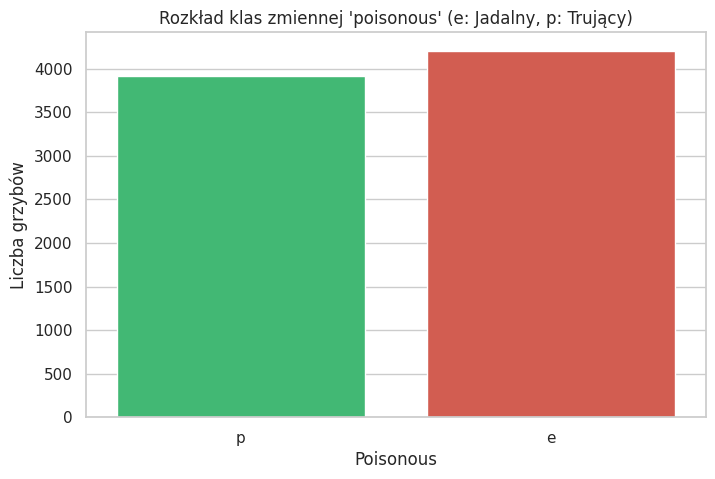

=== 3. ZALEŻNOŚĆ ZAPACHU (odor) OD JADALNOŚCI ===


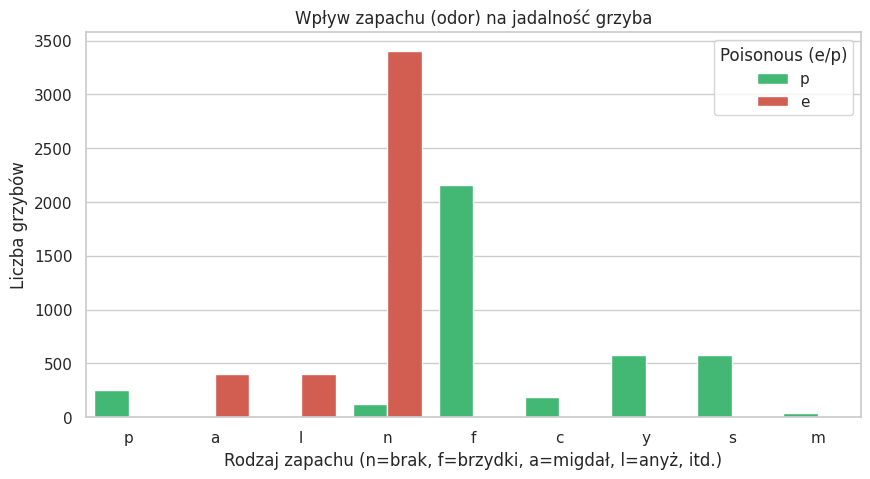

=== 4. ZALEŻNOŚĆ KOLORU ZARODNIKÓW (spore-print-color) ===


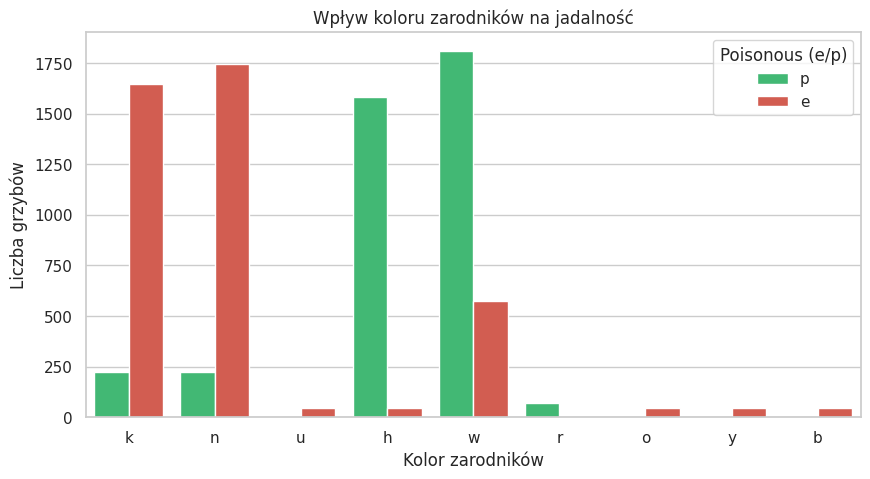

=== 5. MACIERZ KORELACJI CECH KATEGORYCZNYCH ===


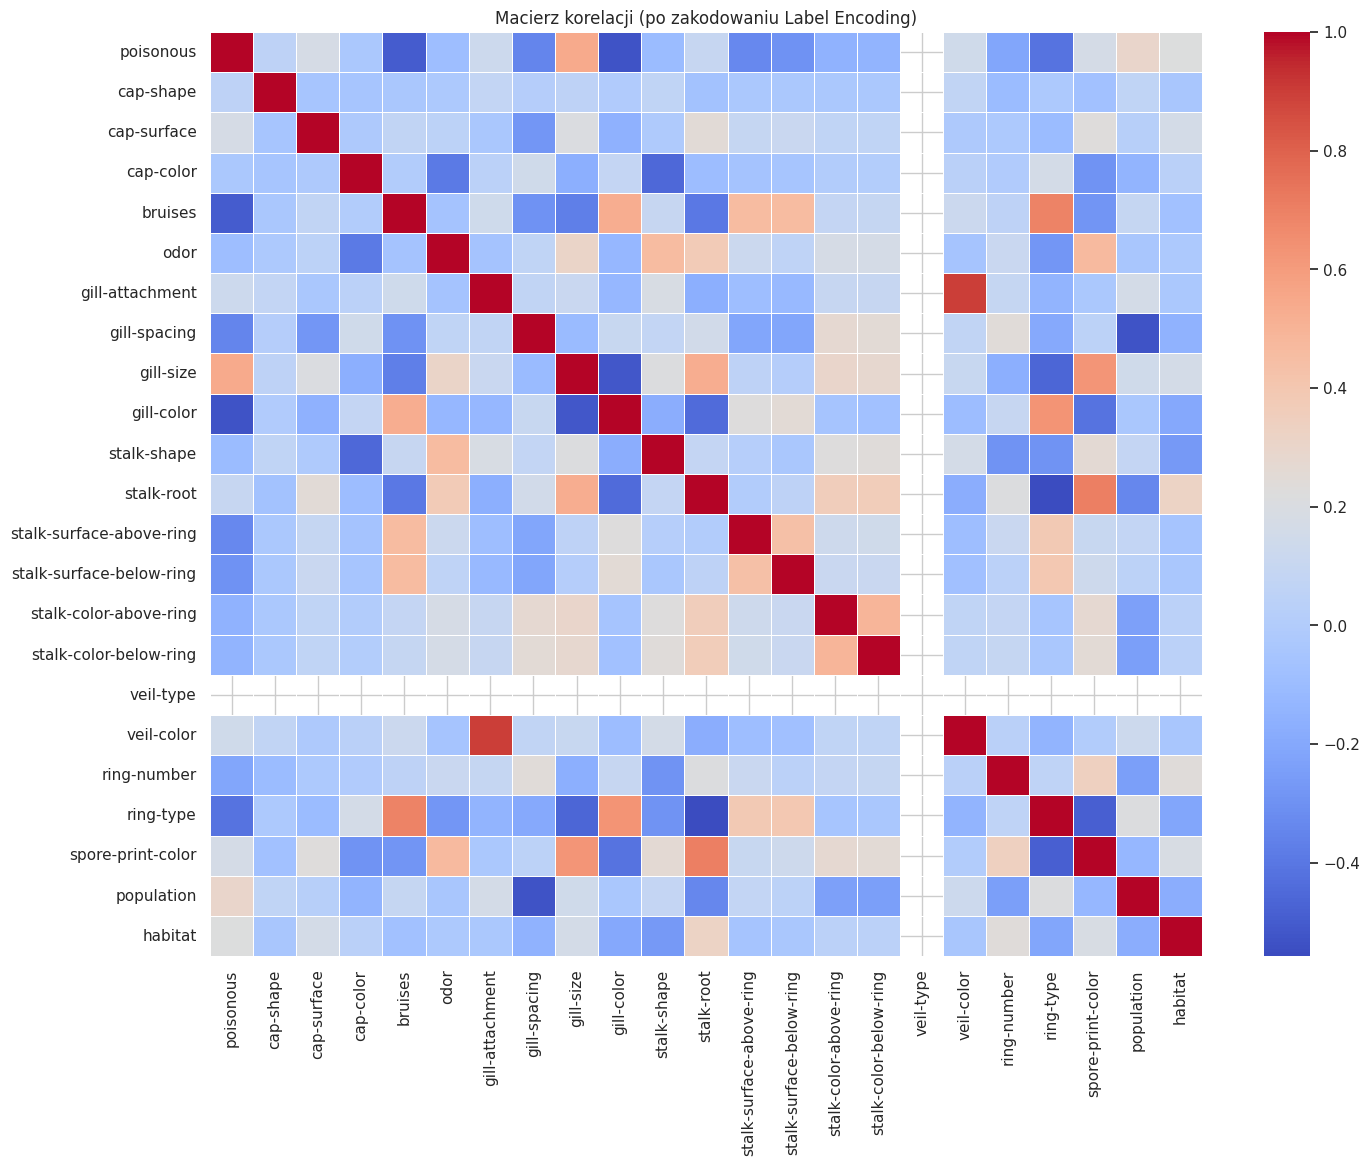

Najsilniejsze powiązania ze zmienną 'poisonous':


,poisonous
poisonous,1.000000
gill-size,0.540024
population,0.298686
habitat,0.217179
cap-surface,0.178446


,poisonous
gill-spacing,-0.348387
ring-type,-0.411771
bruises,-0.501530
gill-color,-0.530566
veil-type,NaN


In [46]:
# Ustawienie stylu
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("=== 1. PODSTAWOWY PRZEGLĄD DANYCH ===")
print(f"Rozmiar zbioru: {df.shape[0]} wierszy i {df.shape[1]} kolumn.\n")

# Zbiór UCI używa '?' jako braku danych - zamieniamy na NaN
df = df.replace('?', np.nan)

print("Brakujące wartości w kolumnach:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n")

print("=== 2. ROZKŁAD ZMIENNEJ DOCELOWEJ (poisonous) ===")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='poisonous', hue='poisonous', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title("Rozkład klas zmiennej 'poisonous' (e: Jadalny, p: Trujący)")
plt.ylabel('Liczba grzybów')
plt.xlabel('Poisonous')
plt.show()

print("=== 3. ZALEŻNOŚĆ ZAPACHU (odor) OD JADALNOŚCI ===")
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='odor', hue='poisonous', palette=['#2ecc71', '#e74c3c'])
plt.title("Wpływ zapachu (odor) na jadalność grzyba")
plt.xlabel('Rodzaj zapachu (n=brak, f=brzydki, a=migdał, l=anyż, itd.)')
plt.ylabel('Liczba grzybów')
plt.legend(title='Poisonous (e/p)')
plt.show()

print("=== 4. ZALEŻNOŚĆ KOLORU ZARODNIKÓW (spore-print-color) ===")
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='spore-print-color', hue='poisonous', palette=['#2ecc71', '#e74c3c'])
plt.title("Wpływ koloru zarodników na jadalność")
plt.xlabel('Kolor zarodników')
plt.ylabel('Liczba grzybów')
plt.legend(title='Poisonous (e/p)')
plt.show()

print("=== 5. MACIERZ KORELACJI CECH KATEGORYCZNYCH ===")
# Używamy LabelEncoder aby zamienić litery na cyfry tylko na potrzeby korelacji
le = LabelEncoder()
df_encoded = pd.DataFrame()

for column in df.columns:
    df_encoded[column] = le.fit_transform(df[column].astype(str))

plt.figure(figsize=(16, 12))
# Liczymy korelację
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Macierz korelacji (po zakodowaniu Label Encoding)")
plt.show()

print("Najsilniejsze powiązania ze zmienną 'poisonous':")
# Wypisujemy kolumny najbardziej skorelowane ze zmienną docelową
korelacje = correlation_matrix['poisonous'].sort_values(ascending=False)
display(korelacje.head(5))
display(korelacje.tail(5))

### Preprocesing

In [47]:

print("=== ROZPOCZĘCIE PREPROCESINGU ===")

# 1. Obsługa braków danych
# Wypełniamy wartości NaN w całym zbiorze słowem 'missing'
df_clean = df.fillna('missing')

# 2. Oddzielenie cech (X) od zmiennej docelowej (y)
X = df_clean.drop('poisonous', axis=1)
y = df_clean['poisonous']

# 3. Kodowanie zmiennej docelowej
# 'e' (edible) stanie się 0, 'p' (poisonous) stanie się 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Klasy po zakodowaniu: {le.classes_} -> [0, 1]")

# 4. One-Hot Encoding dla cech
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. Podział na zbiór treningowy i testowy (80% trening, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\n=== PODSUMOWANIE PO PREPROCESINGU ===")
print(f"Rozmiar X_train (Cechy treningowe): {X_train.shape}")
print(f"Rozmiar X_test (Cechy testowe): {X_test.shape}")

# Podgląd pierwszych 3 wierszy zakodowanych danych
display(X_train.head(3))

=== ROZPOCZĘCIE PREPROCESINGU ===
Klasy po zakodowaniu: ['e' 'p'] -> [0, 1]

=== PODSUMOWANIE PO PREPROCESINGU ===
Rozmiar X_train (Cechy treningowe): (6499, 95)
Rozmiar X_test (Cechy testowe): (1625, 95)


,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
5249,False,True,False,False,False,False,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False
5781,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7586,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,True,False,False,False,False,False


### Uczenie modeli

-> Trenowanie siatki dla modelu: Drzewo Decyzyjne...
-> Trenowanie siatki dla modelu: Regresja Logistyczna...
-> Trenowanie siatki dla modelu: Las Losowy...

=== ZWYCIĘSKIE KONFIGURACJE (NAJLEPSZE PARAMETRY) ===


,Algorytm,Najlepsze Parametry,Najwyższa Dokładność (CV),Czas Optymalizacji [s]
0,Drzewo Decyzyjne,"{'criterion': 'gini', 'max_depth': 7}",0.9997,1.13
1,Regresja Logistyczna,{'C': 10.0},0.9997,1.50
2,Las Losowy,"{'max_depth': None, 'n_estimators': 50}",1.0000,7.78



=== GENEROWANIE WYKRESÓW STATYCZNYCH ===


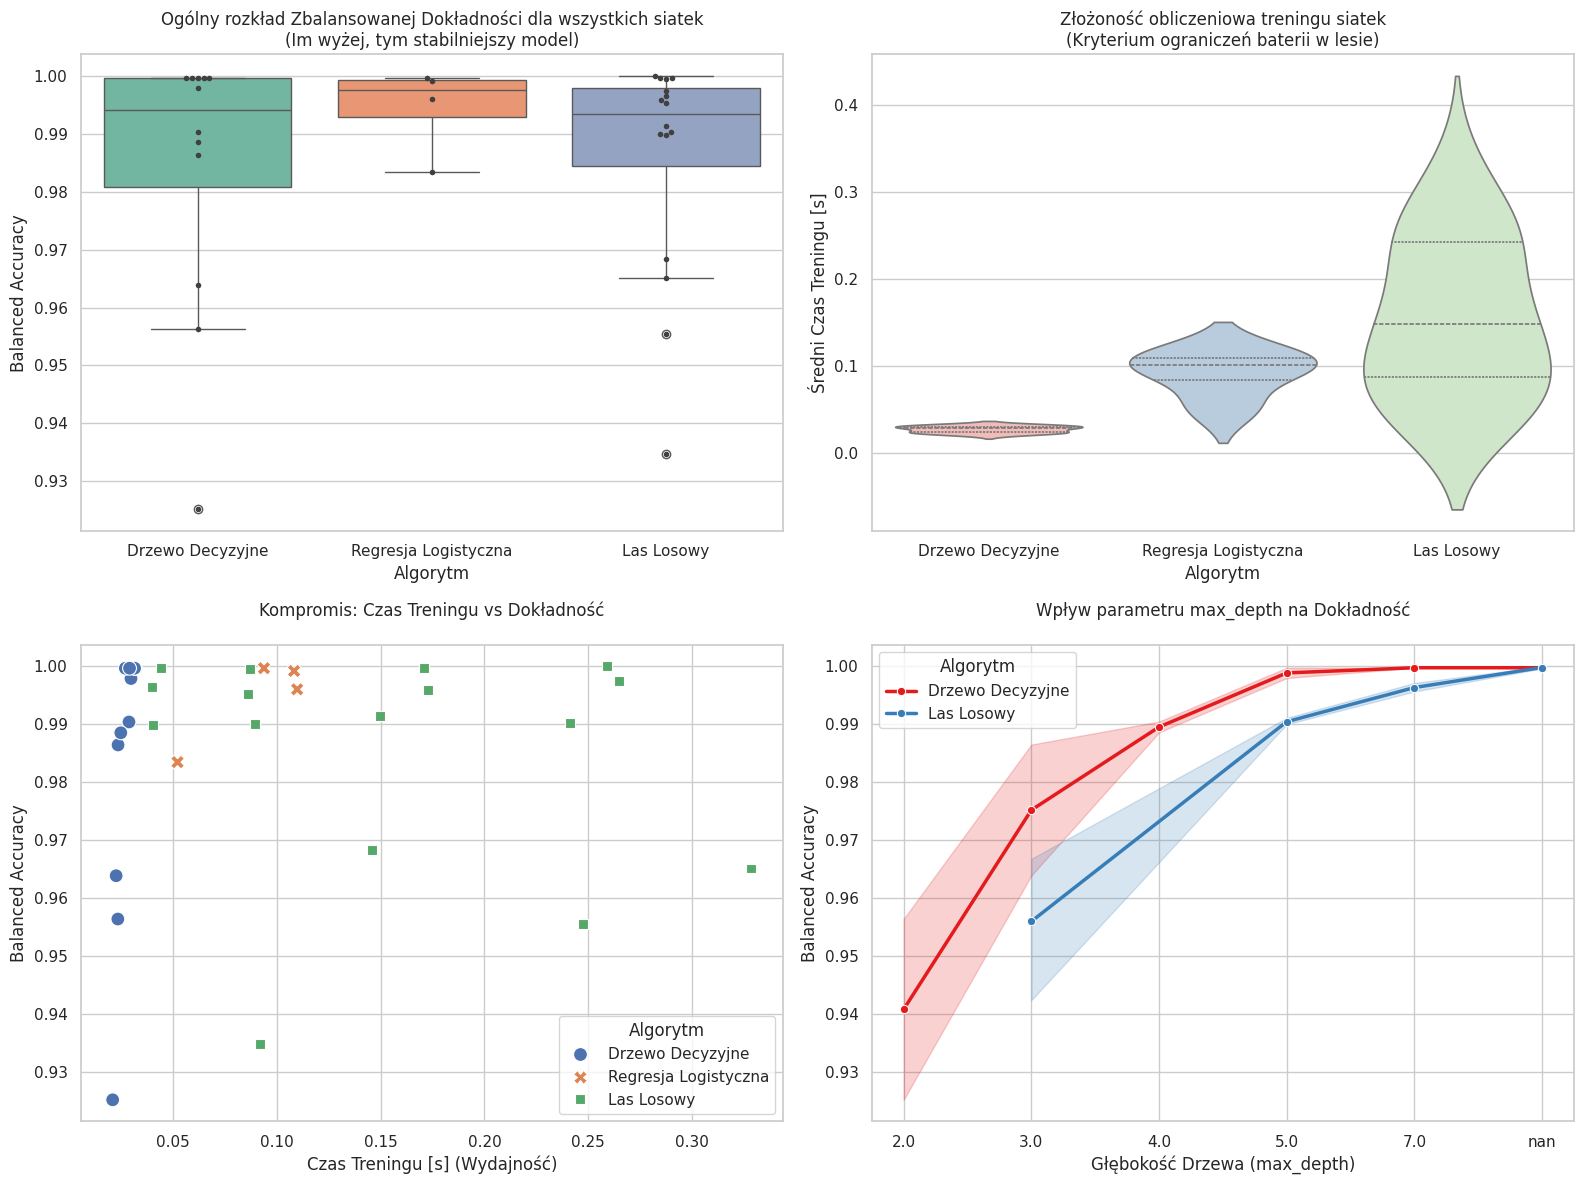


=== PROTOKÓŁ ZAKOŃCZONY ===


In [48]:
# ==========================================
# 1. DEFINICJA MIARY KOSZTU I SIATKI PARAMETRÓW
# ==========================================
score_func = 'balanced_accuracy'

param_grids = {
    "Drzewo Decyzyjne": {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [2, 3, 4, 5, 7, None],
            'criterion': ['gini', 'entropy']
        }
    },
    "Regresja Logistyczna": {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1.0, 10.0]
        }
    },
    "Las Losowy": {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [5, 15, 30, 50],
            'max_depth': [3, 5, 7, None],
        }
    }
}

final_results = []
best_params_summary = []

# ==========================================
# 2. PĘTLA PRZESZUKUJĄCA (Grid Search)
# ==========================================
best_estimators = {}
for name, config in param_grids.items():
    print(f"-> Trenowanie siatki dla modelu: {name}...")

    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring={'Balanced_Accuracy': score_func},
        refit='Balanced_Accuracy',
        cv=5,
        n_jobs=-1,
        return_train_score=False
    )

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    opt_time = time.time() - start_time

    # --- ZAPIS NAJLEPSZYCH PARAMETRÓW ---
    best_params_summary.append({
        "Algorytm": name,
        "Najlepsze Parametry": str(grid_search.best_params_),
        "Najwyższa Dokładność (CV)": round(grid_search.best_score_, 4),
        "Czas Optymalizacji [s]": round(opt_time, 2)
    })

    # Ekstrakcja wyników CV dla wszystkich wariantów do wykresów
    cv_results = grid_search.cv_results_

    for i in range(len(cv_results['params'])):
        params_str = str(cv_results['params'][i])
        avg_fit_time = cv_results['mean_fit_time'][i]

        final_results.append({
            "Algorytm": name,
            "Konfiguracja": params_str,
            "Zbalansowana Dokładność (CV)": cv_results['mean_test_Balanced_Accuracy'][i],
            "Czas Treningu (Fit Time) [s]": avg_fit_time
        })
    best_estimators[name] = grid_search.best_estimator_

opt_df = pd.DataFrame(final_results)

# ==========================================
# 3. WYŚWIETLENIE NAJLEPSZYCH PARAMETRÓW
# ==========================================
print("\n=== ZWYCIĘSKIE KONFIGURACJE (NAJLEPSZE PARAMETRY) ===")
best_df = pd.DataFrame(best_params_summary)
display(best_df)

# ==========================================
# 4. ANALIZA I GENEROWANIE STATYCZNYCH WYKRESÓW
# ==========================================
print("\n=== GENEROWANIE WYKRESÓW STATYCZNYCH ===")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- WYKRES 1: Zbalansowana Dokładność vs Algorytm ---
# POPRAWKA: Dodano hue='Algorytm' oraz legend=False
sns.boxplot(ax=axes[0, 0], data=opt_df, x='Algorytm', y='Zbalansowana Dokładność (CV)', hue='Algorytm', palette='Set2', legend=False)
sns.swarmplot(ax=axes[0, 0], data=opt_df, x='Algorytm', y='Zbalansowana Dokładność (CV)', color='.25', size=4)
axes[0, 0].set_title('Ogólny rozkład Zbalansowanej Dokładności dla wszystkich siatek\n(Im wyżej, tym stabilniejszy model)')
axes[0, 0].set_ylabel('Balanced Accuracy')

# --- WYKRES 2: Czas Treningu vs Algorytm ---
# POPRAWKA: Dodano hue='Algorytm' oraz legend=False
sns.violinplot(ax=axes[0, 1], data=opt_df, x='Algorytm', y='Czas Treningu (Fit Time) [s]', hue='Algorytm', palette='Pastel1', inner='quartile', legend=False)
axes[0, 1].set_title('Złożoność obliczeniowa treningu siatek\n(Kryterium ograniczeń baterii w lesie)')
axes[0, 1].set_ylabel('Średni Czas Treningu [s]')

# --- WYKRES 3: Trade-off: Dokładność vs Czas (Scatterplot) ---
sns.scatterplot(ax=axes[1, 0], data=opt_df, x='Czas Treningu (Fit Time) [s]', y='Zbalansowana Dokładność (CV)',
                hue='Algorytm', style='Algorytm', s=100, palette='deep')
axes[1, 0].set_title('Kompromis: Czas Treningu vs Dokładność\n')
axes[1, 0].set_xlabel('Czas Treningu [s] (Wydajność)')
axes[1, 0].set_ylabel('Balanced Accuracy')

# --- WYKRES 4: Analiza Wpływu max_depth (Dla Drzew i Lasu Losowego) ---
tree_data = opt_df[opt_df['Algorytm'].isin(['Drzewo Decyzyjne', 'Las Losowy'])].copy()
tree_data['Głębokość (max_depth)'] = tree_data['Konfiguracja'].apply(lambda x: eval(x).get('max_depth', 'None')).astype(str)

sns.lineplot(ax=axes[1, 1], data=tree_data, x='Głębokość (max_depth)', y='Zbalansowana Dokładność (CV)',
             hue='Algorytm', marker='o', palette='Set1', linewidth=2.5)
axes[1, 1].set_title('Wpływ parametru max_depth na Dokładność\n')
axes[1, 1].set_xlabel('Głębokość Drzewa (max_depth)')
axes[1, 1].set_ylabel('Balanced Accuracy')

plt.tight_layout()
plt.show()

print("\n=== PROTOKÓŁ ZAKOŃCZONY ===")

In [49]:
final_test_results = []

for name, model in best_estimators.items():
    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time_ms = (time.time() - start_pred) * 1000

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, pos_label=1)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    final_test_results.append({
        "Zoptymalizowany Model": name,
        "Czas Predykcji [ms]": round(pred_time_ms, 3),
        "Zjedzone Trujące (FN)": fn,
        "Wyrzucone Jadalne (FP)": fp,
        "Czułość (na Truciznę)": f"{recall:.2%}",
        "Dokładność": f"{acc:.2%}"
    })

final_df = pd.DataFrame(final_test_results)

final_df = final_df.sort_values(by=["Zjedzone Trujące (FN)", "Czas Predykcji [ms]"], ascending=[True, True])

display(final_df)

,Zoptymalizowany Model,Czas Predykcji [ms],Zjedzone Trujące (FN),Wyrzucone Jadalne (FP),Czułość (na Truciznę),Dokładność
1,Regresja Logistyczna,3.485,0,0,100.00%,100.00%
0,Drzewo Decyzyjne,6.861,0,0,100.00%,100.00%
2,Las Losowy,30.934,0,0,100.00%,100.00%


### Wnioski

1. Rygorystyczna optymalizacja parametrów z wykorzystaniem walidacji krzyżowej pozwoliła na osiągnięcie maksymalnej skuteczności przez wszystkie badane algorytmy. Na zbiorze testowym zoptymalizowane wersje Drzewa Decyzyjnego, Regresji Logistycznej oraz Lasu Losowego uzyskały czułość (Recall) na poziomie 100% dla klasy krytycznej (grzyby trujące). Oznacza to całkowitą eliminację błędów pierwszego rodzaju (False Negatives), co spełnia kluczowy wymóg bezpieczeństwa – system nie zaklasyfikował żadnego obiektu trującego jako jadalnego.

2. W warunkach skrajnych ograniczeń sprzętowych (wyczerpujące się zasilanie, niska moc obliczeniowa), decydującym metryką różnicującą stał się czas predykcji.

Las Losowy (Ensemble): Model zespołowy, wymagający ewaluacji kilkudziesięciu pojedynczych drzew, wykazał znaczne zapotrzebowanie na zasoby (czas predykcji: 29,025 ms). Z uwagi na brak wartości dodanej w postaci wyższej skuteczności względem modeli prostszych, jego wdrożenie stanowiłoby nieuzasadnione marnotrawstwo mocy obliczeniowej. Zostaje on definitywnie odrzucony.

Regresja Logistyczna oraz Drzewo Decyzyjne: Oba modele bazowe wykazały wybitną wydajność, osiągając czasy predykcji odpowiednio: 4,096 ms oraz 5,586 ms. Różnica operacyjna między nimi jest marginalna i w kontekście obciążenia układu scalonego pomijalna.

3. Mimo że Regresja Logistyczna posiada nieznacznie niższy czas egzekucji, to Drzewo Decyzyjne dysponuje przewagą krytyczną: jest tzw. modelem białej skrzynki (white-box model). Działanie regresji opiera się na złożonej funkcji matematycznej z licznymi wagami ułamkowymi, których zastosowanie bez dostępu do procesora jest niemożliwe. Z kolei Drzewo Decyzyjne generuje zbiór jawnych, prostych reguł logicznych.

Do ostatecznego wdrożenia rekomenduje się Drzewo Decyzyjne (konfiguracja optymalna: criterion='gini', max_depth=7).